In [2]:
# Install/import the libraries we need

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [3]:
# Install XGBoost
!pip install -q xgboost

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import urllib.request
import os
import joblib

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [4]:
# Download the dataset

url = (
    "https://d1.awsstatic.com/tmt/build-train-deploy-machine-learning-model-sagemaker/"
    "bank_clean.27f01fbbdf43271788427f3682996ae29ceca05d.csv"
)

filename = "bank_clean.csv"

try:
    urllib.request.urlretrieve(url, filename)
    print("Success: downloaded bank_clean.csv.")
except Exception as e:
    print("Data load error:", e)

# Load the dataset
try:
    model_data = pd.read_csv(filename, index_col=0)
    print("Success: Data loaded into dataframe.")
except Exception as e:
    print("Data load error:", e)

# Display the first 5 rows
model_data.head()


Success: downloaded bank_clean.csv.
Success: Data loaded into dataframe.


,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,y_no,y_yes
0,56,1,999,0,1,0,0,0,0,1,...,0,1,0,0,0,0,1,0,1,0
1,57,1,999,0,1,0,0,0,0,0,...,0,1,0,0,0,0,1,0,1,0
2,37,1,999,0,1,0,0,0,0,0,...,0,1,0,0,0,0,1,0,1,0
3,40,1,999,0,1,0,1,0,0,0,...,0,1,0,0,0,0,1,0,1,0
4,56,1,999,0,1,0,0,0,0,0,...,0,1,0,0,0,0,1,0,1,0


In [5]:
print("Dataset shape:", model_data.shape)

print("\nColumn names:")
print(model_data.columns.tolist())

print("\nFirst 5 rows:")
display(model_data.head())


Dataset shape: (41188, 61)

Column names:
['age', 'campaign', 'pdays', 'previous', 'no_previous_contact', 'not_working', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married', 'marital_single', 'marital_unknown', 'education_basic.4y', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_no', 'default_unknown', 'default_yes', 'housing_no', 'housing_unknown', 'housing_yes', 'loan_no', 'loan_unknown', 'loan_yes', 'contact_cellular', 'contact_telephone', 'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_fri', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_we

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,y_no,y_yes
0,56,1,999,0,1,0,0,0,0,1,...,0,1,0,0,0,0,1,0,1,0
1,57,1,999,0,1,0,0,0,0,0,...,0,1,0,0,0,0,1,0,1,0
2,37,1,999,0,1,0,0,0,0,0,...,0,1,0,0,0,0,1,0,1,0
3,40,1,999,0,1,0,1,0,0,0,...,0,1,0,0,0,0,1,0,1,0
4,56,1,999,0,1,0,0,0,0,0,...,0,1,0,0,0,0,1,0,1,0


In [6]:
# Shuffle the data
shuffled_data = model_data.sample(frac=1, random_state=1729)

# Split 70% training and 30% testing
split_point = int(0.7 * len(shuffled_data))

train_data = shuffled_data.iloc[:split_point].copy()
test_data = shuffled_data.iloc[split_point:].copy()

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)


Training data shape: (28831, 61)
Testing data shape: (12357, 61)


In [7]:
train_data['y_yes']


,y_yes
40949,0
9332,0
32286,0
3925,0
9406,0
...,...
3871,0
16681,0
39272,1
7717,1


In [8]:
# Target variable
y_train = train_data['y_yes']
y_test = test_data['y_yes']

# Remove both target columns from the input features
X_train = train_data.drop(['y_no', 'y_yes'], axis=1)
X_test = test_data.drop(['y_no', 'y_yes'], axis=1)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (28831, 59)
y_train shape: (28831,)
X_test shape: (12357, 59)
y_test shape: (12357,)


In [9]:
# Create XGBoost model

model = XGBClassifier(
    max_depth=5,
    learning_rate=0.2,       # eta in SageMaker
    gamma=4,
    min_child_weight=6,
    subsample=0.8,
    n_estimators=100,        # num_round in SageMaker
    objective='binary:logistic',
    eval_metric='logloss',
    verbosity=0,
    random_state=1729
)

print("Training XGBoost model...")

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully!")


Training XGBoost model...
Model training completed successfully!


In [10]:
# Save the trained model
model_filename = "xgboost_bank_model.joblib"

joblib.dump(model, model_filename)

print("Model saved successfully as:", model_filename)


Model saved successfully as: xgboost_bank_model.joblib


In [11]:
# Load the saved model
deployed_model = joblib.load("xgboost_bank_model.joblib")

print("Model loaded successfully.")
print("Model is ready to make predictions.")


Model loaded successfully.
Model is ready to make predictions.


In [14]:
# Generate predictions

predictions = deployed_model.predict_proba(X_test)[:, 1]

print("Number of predictions:", len(predictions))

# Display first 10 probability predictions
print("\nFirst 10 prediction probabilities:")
print(predictions[:10])


Number of predictions: 12357

First 10 prediction probabilities:
[0.05168192 0.04845993 0.05296427 0.40718764 0.10229376 0.07682865
 0.03718537 0.03829734 0.03726148 0.03164664]


In [15]:
# Convert probabilities to binary predictions
predicted_classes = np.round(predictions).astype(int)

print("First 20 predicted classes:")
print(predicted_classes[:20])


First 20 predicted classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [16]:
# Create confusion matrix

cm = confusion_matrix(y_test, predicted_classes)

print("Confusion Matrix:")
print(cm)

# Extract values
tn, fp, fn, tp = cm.ravel()

# Calculate accuracy
accuracy = (tp + tn) / (tp + tn + fp + fn) * 100

print("\nOverall Classification Rate: {:.2f}%".format(accuracy))


Confusion Matrix:
[[10781   155]
 [ 1141   280]]

Overall Classification Rate: 89.51%


In [17]:
print("\nPredicted        No Purchase     Purchase")
print("Observed")

print(
    "No Purchase      {:>6.1f}% ({})      {:>6.1f}% ({})".format(
        tn / (tn + fn) * 100,
        tn,
        fp / (tp + fp) * 100,
        fp
    )
)

print(
    "Purchase         {:>6.1f}% ({})      {:>6.1f}% ({})".format(
        fn / (tn + fn) * 100,
        fn,
        tp / (tp + fp) * 100,
        tp
    )
)



Predicted        No Purchase     Purchase
Observed
No Purchase        90.4% (10781)        35.6% (155)
Purchase            9.6% (1141)        64.4% (280)


In [18]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        predicted_classes,
        target_names=["No Purchase", "Purchase"]
    )
)


Classification Report:

              precision    recall  f1-score   support

 No Purchase       0.90      0.99      0.94     10936
    Purchase       0.64      0.20      0.30      1421

    accuracy                           0.90     12357
   macro avg       0.77      0.59      0.62     12357
weighted avg       0.87      0.90      0.87     12357



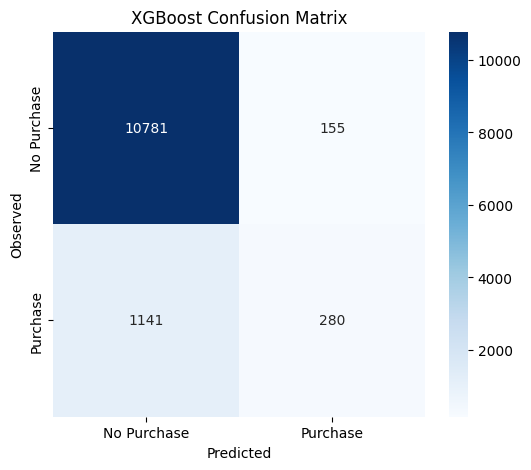

In [19]:
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.xlabel("Predicted")
plt.ylabel("Observed")
plt.title("XGBoost Confusion Matrix")

plt.show()


In [20]:
# Clean up local files

if os.path.exists("bank_clean.csv"):
    os.remove("bank_clean.csv")

if os.path.exists("xgboost_bank_model.joblib"):
    os.remove("xgboost_bank_model.joblib")

print("Local temporary files deleted.")
print("Cleanup completed successfully.")


Local temporary files deleted.
Cleanup completed successfully.
